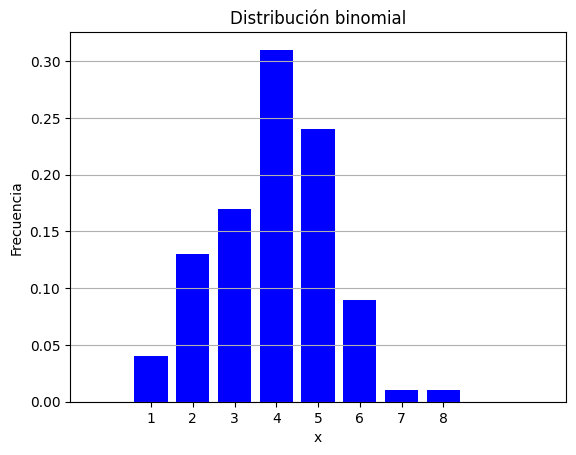

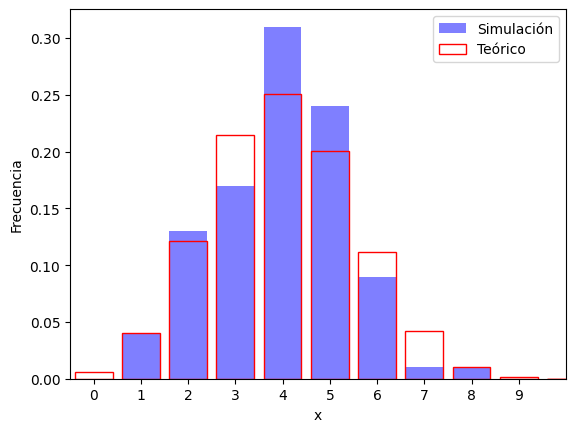

χ² = 6.849278828334415
Valor crítico de χ² = 18.307038053275146
No se rechaza H0: los datos se ajustan a la distribución binomial
p-value = 0.7395932298227209
χ² = 6.849278828334415
p-value = 0.7395932298227209


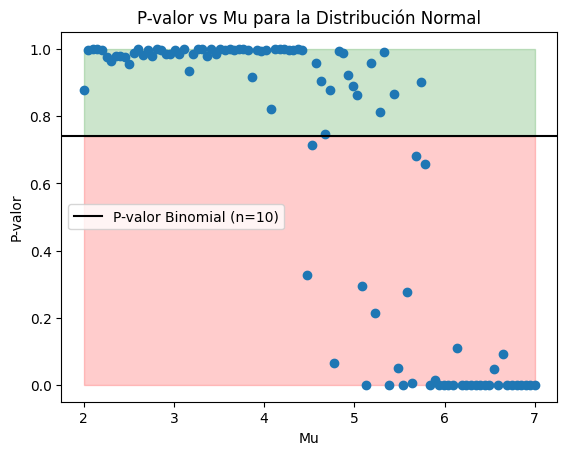

Chi-cuadrado Binomial(1000,0.4): 0.01, P-valor: 1.0000


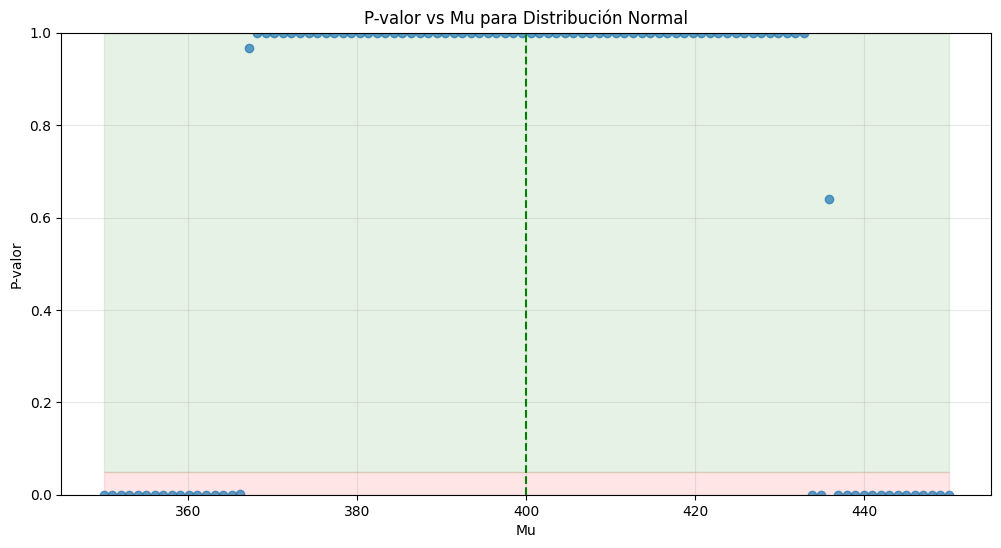

Chi-cuadrado Binomial(1000,0.4): 0.01, P-valor: 1.0000


In [2]:
#importamos librerias
import scipy.stats as sp
import numpy as np
import matplotlib.pyplot as plt

#-------------a----------------#

np.random.seed(25) #Fijamos semilla para reproducibilidad

n, p, t = 10, 0.4, 100 # n = número de ensayos, p = probabilidad de éxito, t = tamaño de la muestra.
datos = np.random.binomial(n, p, t)

m, incompleto = np.unique(datos, return_counts=True)

v = np.zeros(n+1)

v[m] = incompleto

frec = v/t

escala = np.arange(n+1)

plt.bar(escala, frec, color='blue')
plt.xticks(m)
plt.xlabel('x')
plt.ylabel('Frecuencia')
plt.grid(axis='y')
plt.title('Distribución binomial')
plt.show()




#-------------b----------------#

x = np.arange(n+1)
teo = sp.binom.pmf(x, n, p)
plt.bar(escala,frec, color='blue', alpha=0.5, label='Simulación')
plt.bar(x, teo, facecolor='none', edgecolor='red', label='Teórico')
plt.xlabel('x')
plt.ylabel('Frecuencia')
plt.legend()
plt.xticks(x-1)
plt.xlim(-0.5,10)
plt.show()

#Luego, calculamos el estadístico:
a=teo*t #Frecuencia absoluta teórica, pues sp.binom.pmf me devuelve relativas.

chi = 0
for i in range(len(v)):
    chi += ((v[i] - a[i])**2) / a[i]

print('χ² =', chi)

#-------------c----------------#

alpha = 0.05
gl = n 
chi2_critico = sp.chi2.ppf(1 - alpha, gl)
print('Valor crítico de χ² =', chi2_critico)

if chi < chi2_critico:
    print('No se rechaza H0: los datos se ajustan a la distribución binomial')
else:
    print('Se rechaza H0: los datos no se ajustan a la distribución binomial')

#-------------d----------------#

#calculamos p-value

p_value = 1 - sp.chi2.cdf(chi, gl)
print('p-value =', p_value)

#podemos contrastar los resultados usando sp.chisquare

chifacil, pfacil = sp.chisquare(v, a)
print('χ² =', chifacil)
print('p-value =', pfacil)


#-------------e----------------#

mu = np.linspace(2,7,100)
chig=[]
pg=[]

for i in range(100):
    gauss = np.random.normal(loc=mu[i], scale=2.5, size=100)
    gauss_discreto = np.histogram(gauss, bins=11, range=(-0.5,10.5))
    gauss_discreto=np.array(gauss_discreto[0]/np.sum(gauss_discreto[0]))
    l, k = sp.chisquare(gauss_discreto, teo)
    chig.append(l)
    pg.append(k)




#plot
plt.show()

plt.plot(mu,pg,'o')
plt.xlabel('Mu')
plt.ylabel('P-valor')
plt.axhline(pfacil, color='black', label='P-valor Binomial (n=10)')

plt.fill_between(mu, 0, pfacil, color='red', alpha=0.2)
plt.fill_between(mu, pfacil, 1, color='green', alpha=0.2)
plt.title('P-valor vs Mu para la Distribución Normal')
plt.legend()
plt.show()



#-------------f----------------#

# Simule una muestra de 10000 realizaciones de una V.A. con f(x) ∼ B(n = 1000, p = 0.4) y repita el punto anterior

# parámetros de la nueva binomial
n_binomial = 1000
p_binomial = 0.4
size_muestra = 10000

# Calculamos la distribución teórica para B(1000, 0.4)
teo_f = np.array([sp.binom.pmf(k, n_binomial, p_binomial) for k in range(n_binomial + 1)])

# Simulamos muestra grande de binomial
muestra_grande = np.random.binomial(n_binomial, p_binomial, size_muestra)

# Creamos histograma
hist_grande = np.histogram(muestra_grande, bins=n_binomial + 1, range=(-0.5, n_binomial + 0.5))
frec_obs_grande = hist_grande[0] / np.sum(hist_grande[0])

# FILTRAR bins donde la frecuencia esperada es significativa
umbral = 1e-10
indices_validos = teo_f > umbral

teo_f_filtrado = teo_f[indices_validos]
frec_obs_filtrada = frec_obs_grande[indices_validos]

# Normalizamos después del filtrado
teo_f_filtrado = teo_f_filtrado / np.sum(teo_f_filtrado)
frec_obs_filtrada = frec_obs_filtrada / np.sum(frec_obs_filtrada)

# Calcular chi-cuadrado para la nueva binomial
chi2_grande, p_grande = sp.chisquare(frec_obs_filtrada, teo_f_filtrado)

print(f'Chi-cuadrado Binomial(1000,0.4): {chi2_grande:.2f}, P-valor: {p_grande:.4f}')

# Ahora el estudio con normales variando mu
media_binomial = n_binomial * p_binomial  # 400
sigma_big = np.sqrt(n_binomial * p_binomial * (1 - p_binomial))  # ~15.49

mu_big = np.linspace(350, 450, 100)  # Rango alrededor de 400
chig_f = []
pg_f = []

for i in range(100):
    gauss = np.random.normal(loc=mu_big[i], scale=sigma_big, size=size_muestra)  # Usar mu_big[i]
    
    # Discretizamos la normal
    gauss_discreto = np.histogram(gauss, bins=n_binomial + 1, range=(-0.5, n_binomial + 0.5))
    gauss_discreto = np.array(gauss_discreto[0] / np.sum(gauss_discreto[0]))
    
    # Aplicamos el mismo filtro a la distribución normal
    gauss_filtrado = gauss_discreto[indices_validos]
    gauss_filtrado = gauss_filtrado / np.sum(gauss_filtrado)
    
    # Calculamos chi-cuadrado con las distribuciones filtradas
    l, k = sp.chisquare(gauss_filtrado, teo_f_filtrado)
    
    chig_f.append(l)
    pg_f.append(k)

# Plot 
plt.figure(figsize=(12, 6))
plt.plot(mu_big, pg_f, 'o', alpha=0.7, label='P-valor para distribución Normal')
plt.xlabel('Mu')
plt.ylabel('P-valor')


# Marcar la media real de la binomial
plt.axvline(media_binomial, color='green', linestyle='--', label=f'Media binomial = {media_binomial}')

plt.fill_between(mu_big, 0, 0.05, color='red', alpha=0.1, label='Rechazar H0')
plt.fill_between(mu_big, 0.05, 1, color='green', alpha=0.1, label='No rechazar H0')

plt.title('P-valor vs Mu para Distribución Normal')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

print(f'Chi-cuadrado Binomial(1000,0.4): {chi2_grande:.2f}, P-valor: {p_grande:.4f}')